### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load DataSet

In [3]:
df = pd.read_csv('credit_score.csv')

In [4]:
df.head()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


In [5]:
df.shape

(1000, 87)

### Exploratory Data Analysis

In [6]:
# Keep only the required columns
df = df[[
    'INCOME',
    'SAVINGS',
    'DEBT',
    'R_SAVINGS_INCOME',
    'R_DEBT_INCOME',
    'R_DEBT_SAVINGS',
    'CAT_GAMBLING',
    'CAT_DEBT',
    'CAT_CREDIT_CARD',
    'CAT_MORTGAGE',
    'CAT_SAVINGS_ACCOUNT',
    'CAT_DEPENDENTS',
    'CREDIT_SCORE',
    'DEFAULT'
]]

# Features (X) and Target (y)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

In [7]:
df.head()

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,33269,0,532304,0.0000,16.0000,1.2000,High,1,0,0,0,0,444,1
1,77158,91187,315648,1.1818,4.0909,3.4615,No,1,0,0,1,0,625,0
2,30917,21642,534864,0.7000,17.3000,24.7142,High,1,0,0,1,0,469,1
3,80657,64526,629125,0.8000,7.8000,9.7499,High,1,0,0,1,0,559,0
4,149971,1172498,2399531,7.8182,16.0000,2.0465,High,1,1,1,1,1,473,0


In [8]:
df.shape

(1000, 14)

In [9]:
df.columns

Index(['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME',
       'R_DEBT_SAVINGS', 'CAT_GAMBLING', 'CAT_DEBT', 'CAT_CREDIT_CARD',
       'CAT_MORTGAGE', 'CAT_SAVINGS_ACCOUNT', 'CAT_DEPENDENTS', 'CREDIT_SCORE',
       'DEFAULT'],
      dtype='object')

In [10]:
df.isnull().sum()

INCOME                 0
SAVINGS                0
DEBT                   0
R_SAVINGS_INCOME       0
R_DEBT_INCOME          0
R_DEBT_SAVINGS         0
CAT_GAMBLING           0
CAT_DEBT               0
CAT_CREDIT_CARD        0
CAT_MORTGAGE           0
CAT_SAVINGS_ACCOUNT    0
CAT_DEPENDENTS         0
CREDIT_SCORE           0
DEFAULT                0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INCOME               1000 non-null   int64  
 1   SAVINGS              1000 non-null   int64  
 2   DEBT                 1000 non-null   int64  
 3   R_SAVINGS_INCOME     1000 non-null   float64
 4   R_DEBT_INCOME        1000 non-null   float64
 5   R_DEBT_SAVINGS       1000 non-null   float64
 6   CAT_GAMBLING         1000 non-null   object 
 7   CAT_DEBT             1000 non-null   int64  
 8   CAT_CREDIT_CARD      1000 non-null   int64  
 9   CAT_MORTGAGE         1000 non-null   int64  
 10  CAT_SAVINGS_ACCOUNT  1000 non-null   int64  
 11  CAT_DEPENDENTS       1000 non-null   int64  
 12  CREDIT_SCORE         1000 non-null   int64  
 13  DEFAULT              1000 non-null   int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 109.5+ KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,121610.019000,4.131896e+05,7.907180e+05,4.063477,6.068449,5.867252,0.944000,0.236000,0.173000,0.993000,0.15000,586.712000,0.284000
std,113716.699591,4.429160e+05,9.817904e+05,3.968097,5.847878,16.788356,0.230037,0.424835,0.378437,0.083414,0.35725,63.413882,0.451162
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000
25%,30450.250000,5.971975e+04,5.396675e+04,1.000000,1.454500,0.206200,1.000000,0.000000,0.000000,1.000000,0.00000,554.750000,0.000000
50%,85090.000000,2.738505e+05,3.950955e+05,2.545450,4.911550,2.000000,1.000000,0.000000,0.000000,1.000000,0.00000,596.000000,0.000000
75%,181217.500000,6.222600e+05,1.193230e+06,6.307100,8.587475,4.509600,1.000000,0.000000,0.000000,1.000000,0.00000,630.000000,1.000000
max,662094.000000,2.911863e+06,5.968620e+06,16.111200,37.000600,292.842100,1.000000,1.000000,1.000000,1.000000,1.00000,800.000000,1.000000


#### Value Counts

In [14]:
def explore(df, feature_name):
    if df[feature_name].dtype in [np.int64, np.float64]:
        print("************************")
        print("Feature Name : ", feature_name)
        print("Value Counts : ", df[feature_name].value_counts())
        print("************************\n")

In [15]:
for feature in df.columns:
    explore(df, feature)

************************
Feature Name :  INCOME
Value Counts :  INCOME
0         50
11371      1
3935       1
172144     1
220838     1
          ..
18830      1
328892     1
81404      1
36011      1
4574       1
Name: count, Length: 951, dtype: int64
************************

************************
Feature Name :  SAVINGS
Value Counts :  SAVINGS
0          7
1228       2
3268       2
64526      1
1172498    1
          ..
1465066    1
88805      1
42428      1
8002       1
309859     1
Name: count, Length: 992, dtype: int64
************************

************************
Feature Name :  DEBT
Value Counts :  DEBT
0          56
30749       2
4802        2
629125      1
2399531     1
           ..
5501471     1
680837      1
30760       1
604181      1
534864      1
Name: count, Length: 943, dtype: int64
************************

************************
Feature Name :  R_SAVINGS_INCOME
Value Counts :  R_SAVINGS_INCOME
1.0000     21
0.0000     17
0.2000     16
1.5000     15
3.0000 

### Separate Numerical & Categorical Features

In [16]:
num_feature = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_feature = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

In [17]:
print("Numerical Features : ", num_feature)
print("Categorical Features : ", cat_feature)

Numerical Features :  ['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'CAT_DEBT', 'CAT_CREDIT_CARD', 'CAT_MORTGAGE', 'CAT_SAVINGS_ACCOUNT', 'CAT_DEPENDENTS', 'CREDIT_SCORE', 'DEFAULT']
Categorical Features :  ['CAT_GAMBLING']


### Visuallization

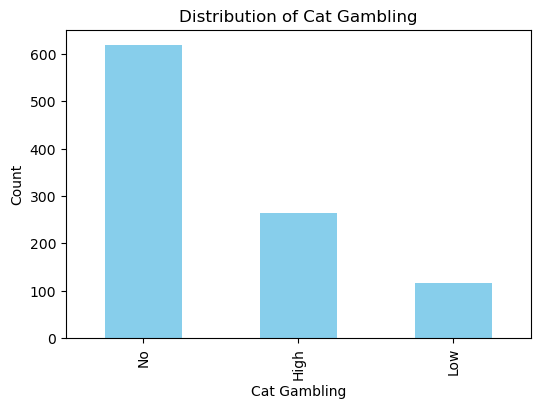

In [18]:
plt.figure(figsize=(6, 4))
df['CAT_GAMBLING'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Cat Gambling")
plt.xlabel("Cat Gambling")
plt.ylabel("Count")
plt.show()

#### Numerical Features

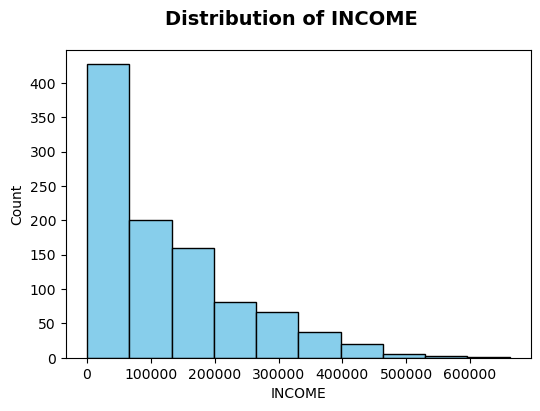

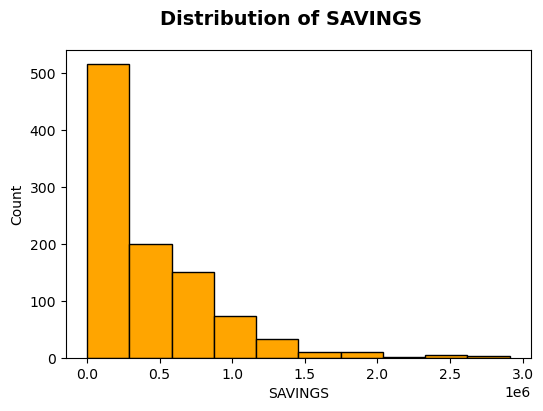

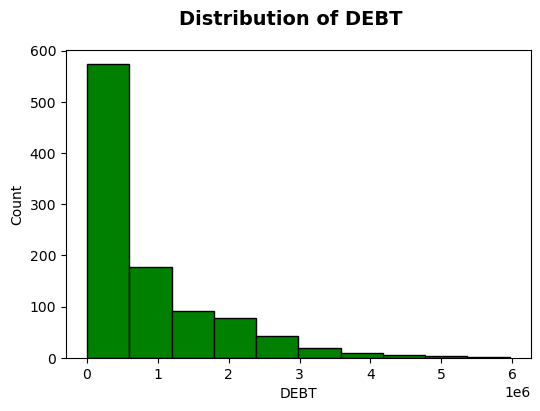

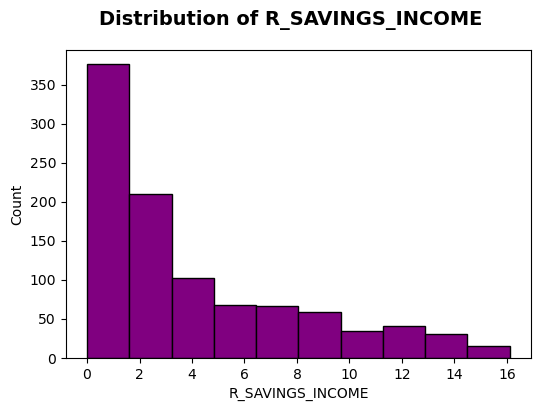

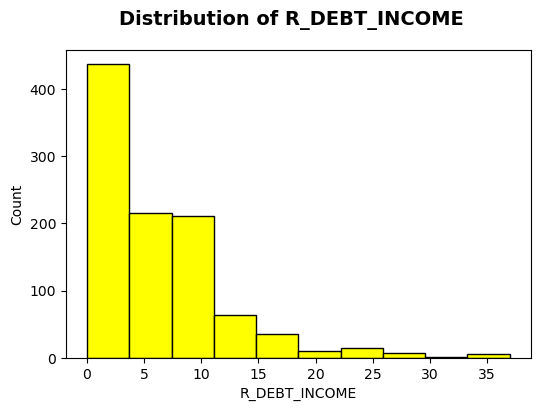

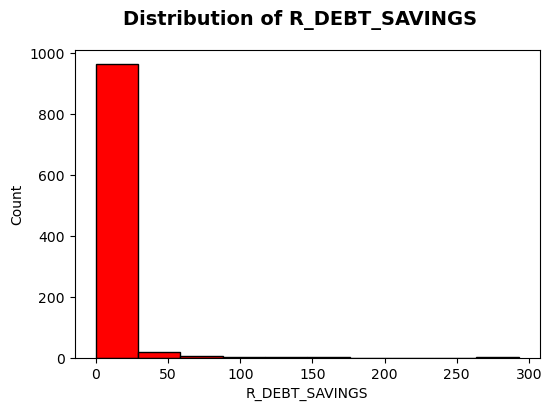

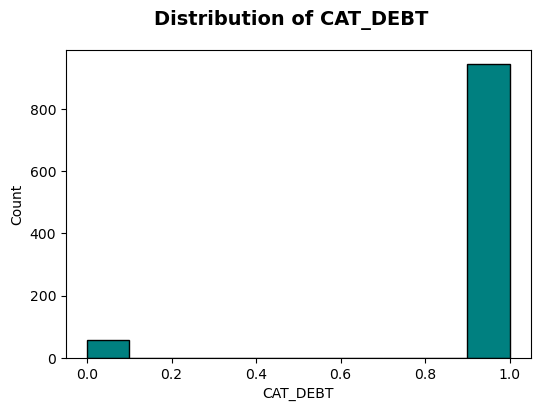

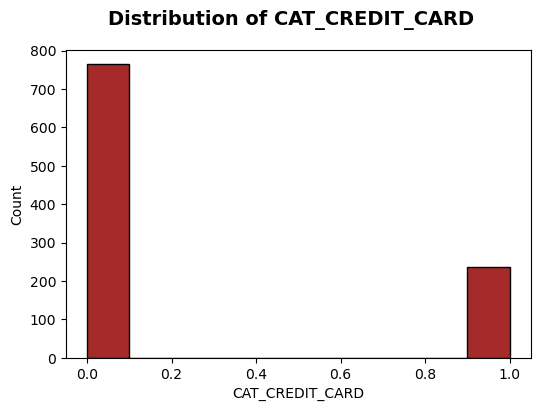

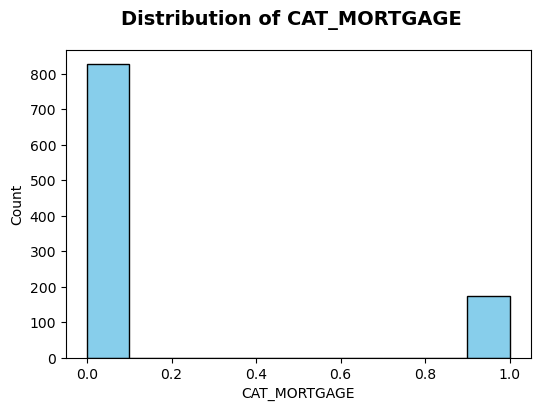

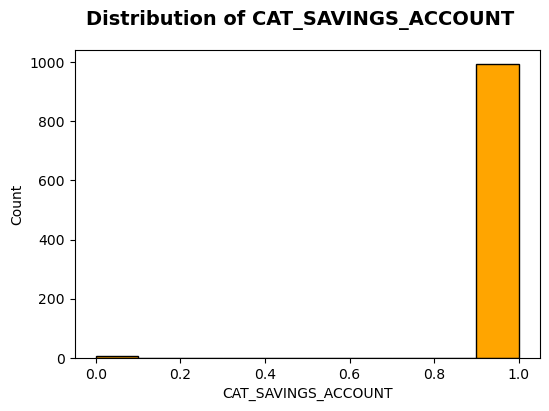

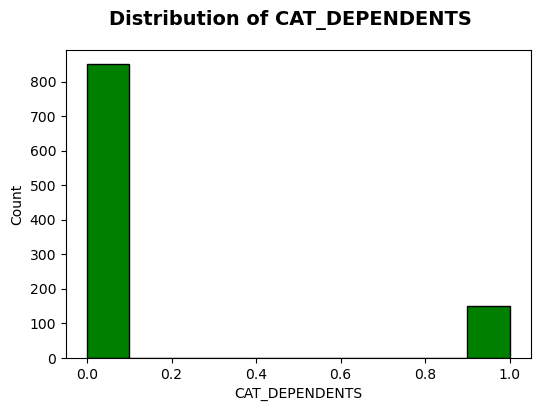

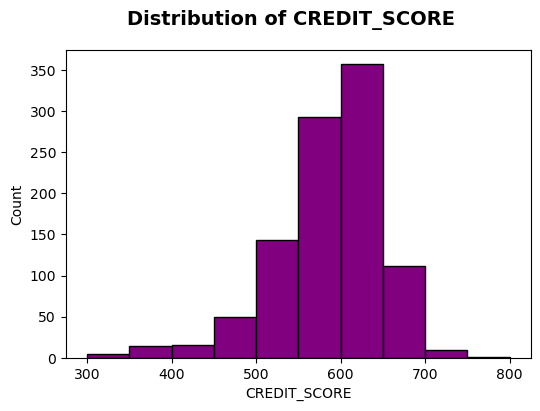

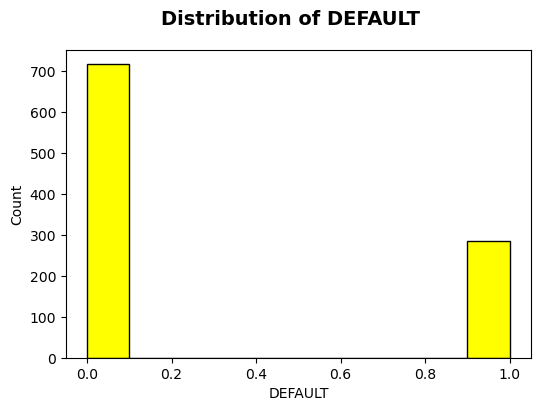

In [19]:
colors = ['skyblue', 'orange', 'green', 'purple', 'yellow', 'red', 'teal', 'brown']

for i, col in enumerate(num_feature):
    plt.figure(figsize=(6, 4))
    plt.suptitle(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.hist(df[col], bins=10, color=colors[i % len(colors)], edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

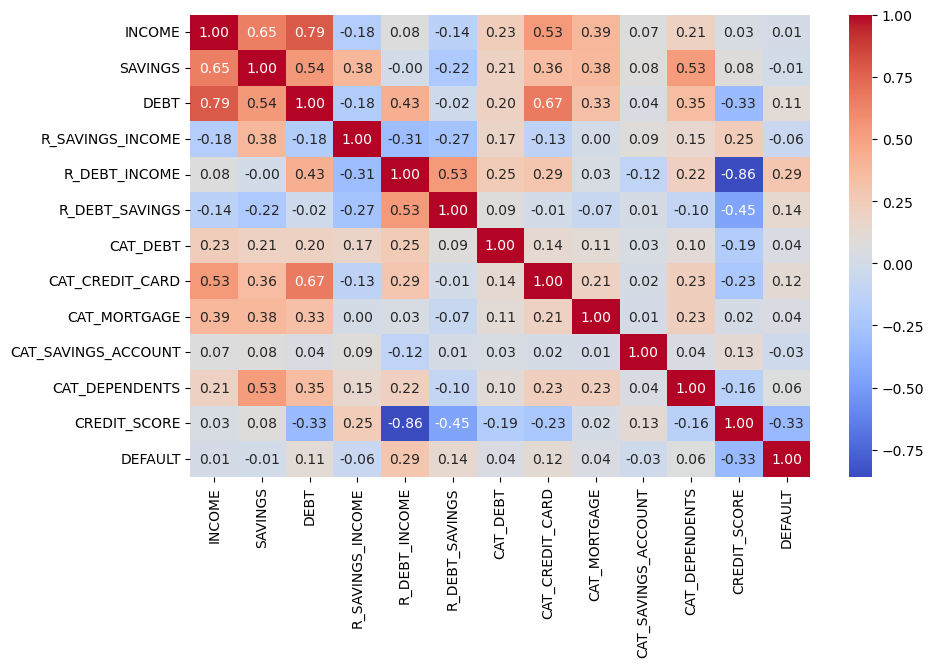

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Check OutLiers

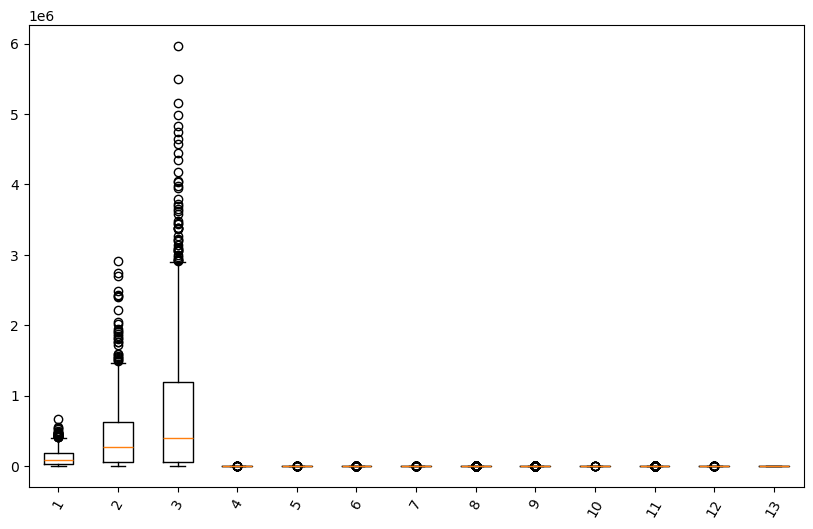

In [21]:
plt.figure(figsize=(10, 6))
plt.boxplot(df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=60)
plt.show()

In [22]:
def return_bounds(df, feature):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

In [23]:
!pip install feature_engine

In [24]:
from feature_engine.outliers import ArbitraryOutlierCapper

In [25]:
for feature in num_feature:
    lower_bound, upper_bound = return_bounds(df, feature)
    arb = ArbitraryOutlierCapper(min_capping_dict={feature: lower_bound}, max_capping_dict={feature: upper_bound})
    df = arb.fit_transform(df)

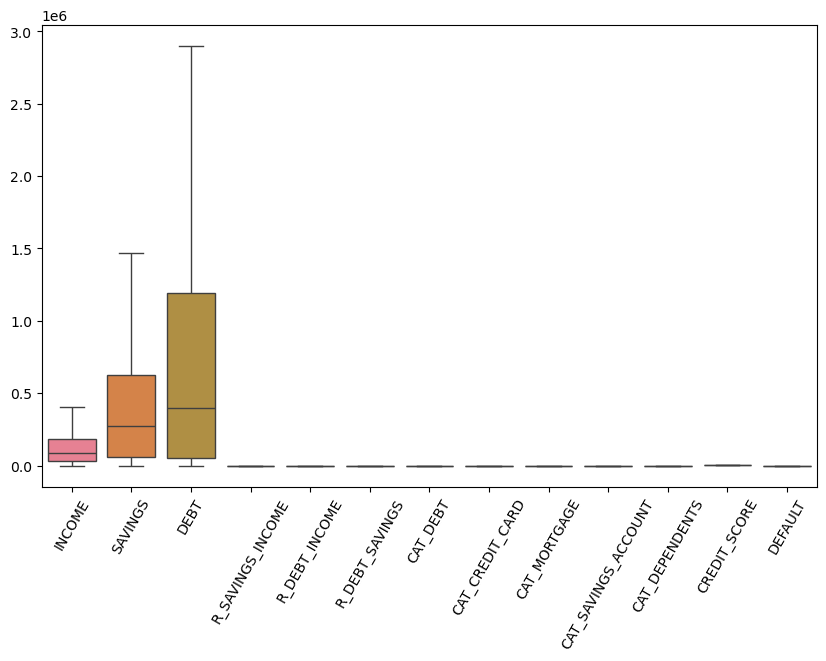

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(df)
plt.xticks(rotation=60)
plt.show()

In [27]:
df.isnull().sum()

INCOME                 0
SAVINGS                0
DEBT                   0
R_SAVINGS_INCOME       0
R_DEBT_INCOME          0
R_DEBT_SAVINGS         0
CAT_GAMBLING           0
CAT_DEBT               0
CAT_CREDIT_CARD        0
CAT_MORTGAGE           0
CAT_SAVINGS_ACCOUNT    0
CAT_DEPENDENTS         0
CREDIT_SCORE           0
DEFAULT                0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

### Train Test Split

In [29]:
X

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE
0,33269,0,532304,0.0000,16.0000,1.2000,High,1,0,0,0,0,444
1,77158,91187,315648,1.1818,4.0909,3.4615,No,1,0,0,1,0,625
2,30917,21642,534864,0.7000,17.3000,24.7142,High,1,0,0,1,0,469
3,80657,64526,629125,0.8000,7.8000,9.7499,High,1,0,0,1,0,559
4,149971,1172498,2399531,7.8182,16.0000,2.0465,High,1,1,1,1,1,473
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,328892,1465066,5501471,4.4546,16.7273,3.7551,High,1,1,1,1,1,418
996,81404,88805,680837,1.0909,8.3637,7.6667,No,1,0,0,1,0,589
997,0,42428,30760,3.2379,8.1889,0.7250,No,1,0,0,1,0,499
998,36011,8002,604181,0.2222,16.7777,75.5037,No,1,1,0,1,0,507


In [30]:
y

0      1
1      0
2      1
3      0
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: DEFAULT, Length: 1000, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

### Scalling

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
num_feature = [col for col in num_feature if col != 'DEFAULT']

In [34]:
x_train[num_feature] = scaler.fit_transform(x_train[num_feature])
x_test[num_feature] = scaler.transform(x_test[num_feature])

### Model Traning

#### Install XGBoost

In [36]:
!pip install xgboost

In [37]:
import xgboost as xgb

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [39]:
lr = LogisticRegression()
svm = SVC(kernel = 'poly', degree=2)
rf = RandomForestClassifier(n_estimators=500, random_state=42)
xg = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.3, objective='binary:logistic', alpha=0.1)

In [40]:
lr.fit(x_train[num_feature], y_train)
svm.fit(x_train[num_feature], y_train)
rf.fit(x_train[num_feature], y_train)
xg.fit(x_train[num_feature], y_train)

XGBClassifier(alpha=0.1, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
lr_pred  = lr.predict(x_test[num_feature])
svm_pred = svm.predict(x_test[num_feature])
rf_pred  = rf.predict(x_test[num_feature])
xg_pred  = xg.predict(x_test[num_feature])

## Cross Val Score

In [42]:
from sklearn.model_selection import cross_val_score
lr_score = np.mean(cross_val_score(lr, x_train[num_feature], y_train, scoring='accuracy', cv=10))
print(f"Logistic Regression Cross Val Score : {lr_score}\n")
svm_score = np.mean(cross_val_score(svm, x_train[num_feature], y_train, scoring='accuracy', cv=10))
print(f"SVM Cross Val Score : {svm_score}\n")
rf_score = np.mean(cross_val_score(rf, x_train[num_feature], y_train, scoring='accuracy', cv=10))
print(f"Random Forest Cross Val Score : {rf_score}\n")
xg_score = np.mean(cross_val_score(xg, x_train[num_feature], y_train, scoring='accuracy', cv=10))
print(f"XGBoost Cross Val Score : {xg_score}\n")

Logistic Regression Cross Val Score : 0.7449999999999999

SVM Cross Val Score : 0.73125

Random Forest Cross Val Score : 0.7212500000000001

XGBoost Cross Val Score : 0.71375



### Accuracy Score

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(f"Logistic Regression Accuracy Score : {accuracy_score(y_test, lr_pred)}")
print(f"SVM Accuracy Score : {accuracy_score(y_test, svm_pred)}")
print(f"Random Forest Accuracy Score : {accuracy_score(y_test, rf_pred)}")
print(f"XGBoost Accuracy Score : {accuracy_score(y_test, xg_pred)}")

Logistic Regression Accuracy Score : 0.72
SVM Accuracy Score : 0.735
Random Forest Accuracy Score : 0.69
XGBoost Accuracy Score : 0.67


### Classification Matrices

In [44]:
from sklearn.metrics import confusion_matrix

# LogisticRegression

print(f"Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, lr_pred))

Logistic Regression Confusion Matrix



,0,1
0,135,7
1,49,9


In [45]:
# SVM

print(f"SVM Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, svm_pred))

SVM Confusion Matrix



,0,1
0,141,1
1,52,6


In [46]:
# RandomForestClassifier

print(f"Random Forest Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, rf_pred))

Random Forest Confusion Matrix



,0,1
0,128,14
1,48,10


In [47]:
# XGBClassifier

print(f"XGBoost Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, xg_pred))

XGBoost Confusion Matrix



,0,1
0,124,18
1,48,10


### Classifiction Reports

In [48]:
from sklearn.metrics import classification_report
print("\n======== Logistic Regression Classification Report ========\n")
print(classification_report(y_test, lr_pred))

print("\n======== SVM Classification Report ========\n")
print(classification_report(y_test, svm_pred))


======== Logistic Regression Classification Report ========

              precision    recall  f1-score   support

           0       0.73      0.95      0.83       142
           1       0.56      0.16      0.24        58

    accuracy                           0.72       200
   macro avg       0.65      0.55      0.54       200
weighted avg       0.68      0.72      0.66       200


======== SVM Classification Report ========

              precision    recall  f1-score   support

           0       0.73      0.99      0.84       142
           1       0.86      0.10      0.18        58

    accuracy                           0.73       200
   macro avg       0.79      0.55      0.51       200
weighted avg       0.77      0.73      0.65       200



In [49]:
print("\n======== RandomForest Classification Report ========\n")
print(classification_report(y_test, rf_pred))

print("\n======== XGBoost Classification Report ========\n")
print(classification_report(y_test, xg_pred))


======== RandomForest Classification Report ========

              precision    recall  f1-score   support

           0       0.73      0.90      0.81       142
           1       0.42      0.17      0.24        58

    accuracy                           0.69       200
   macro avg       0.57      0.54      0.52       200
weighted avg       0.64      0.69      0.64       200


======== XGBoost Classification Report ========

              precision    recall  f1-score   support

           0       0.72      0.87      0.79       142
           1       0.36      0.17      0.23        58

    accuracy                           0.67       200
   macro avg       0.54      0.52      0.51       200
weighted avg       0.62      0.67      0.63       200



Logistic Regression ROC-AUC Score : 0.6586
SVM ROC-AUC Score                 : 0.5908
Random Forest ROC-AUC Score       : 0.5571
XGBoost ROC-AUC Score             : 0.5086


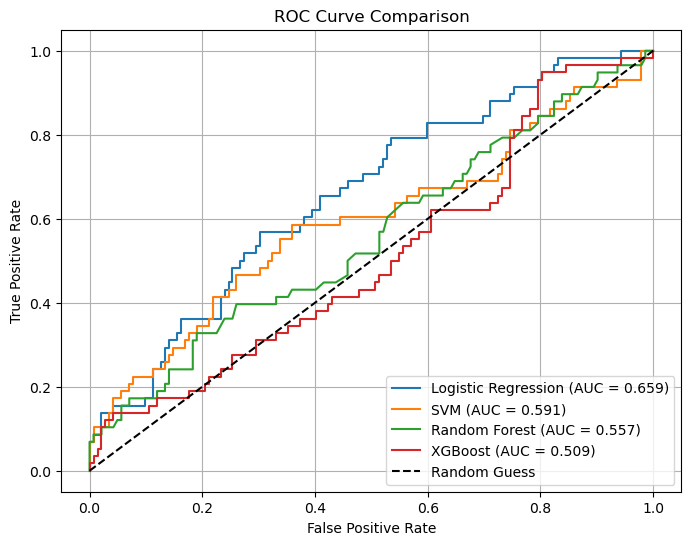

In [52]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -----------------------------
# Predicted probabilities/scores
# -----------------------------

# Logistic Regression
lr_prob = lr.predict_proba(x_test[num_feature])[:, 1]

# SVM (use decision_function instead of predict_proba)
svm_score = svm.decision_function(x_test[num_feature])

# Random Forest
rf_prob = rf.predict_proba(x_test[num_feature])[:, 1]

# XGBoost
xg_prob = xg.predict_proba(x_test[num_feature])[:, 1]

# -----------------------------
# ROC-AUC Scores
# -----------------------------

print(f"Logistic Regression ROC-AUC Score : {roc_auc_score(y_test, lr_prob):.4f}")
print(f"SVM ROC-AUC Score                 : {roc_auc_score(y_test, svm_score):.4f}")
print(f"Random Forest ROC-AUC Score       : {roc_auc_score(y_test, rf_prob):.4f}")
print(f"XGBoost ROC-AUC Score             : {roc_auc_score(y_test, xg_prob):.4f}")

# -----------------------------
# ROC Curves
# -----------------------------

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_score)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xg_fpr, xg_tpr, _ = roc_curve(y_test, xg_prob)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})')

plt.plot(svm_fpr, svm_tpr,
         label=f'SVM (AUC = {roc_auc_score(y_test, svm_score):.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})')

plt.plot(xg_fpr, xg_tpr,
         label=f'XGBoost (AUC = {roc_auc_score(y_test, xg_prob):.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()